# Phase B Session 2: Calibration
## SU-HBO Utility Function Validation

**Goal**: Validate that the utility function U(A) = -E_floor(J,γ) + λ·β(γ)
correctly ranks architectures by early training performance.

**Data**: 5% CIFAR-10 (held-out from main search)
**Architectures**: 8 diverse configs
**Training**: 5 epochs × 10% data per arch

**Success Criteria**:
- Utility ranking correlates with L1 loss ranking (r > 0.7)
- Action effects have correct directions

## 1. Setup

In [1]:
%cd /kaggle/working
!rm -rf ThermoRG-NN
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
gh_token = user_secrets.get_secret("gh_token")
repo_url = f"https://{gh_token}@github.com/xliu203/ThermoRG-NN.git"
!git clone {repo_url} --branch develop
%cd /kaggle/working/ThermoRG-NN
!git config --global user.email "xliu203@asu.edu"
!git config --global user.name "Leo Liu"
print("Cloned develop branch")

/kaggle/working
Cloning into 'ThermoRG-NN'...
remote: Enumerating objects: 853, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (195/195), done.
remote: Total 853 (delta 92), reused 132 (delta 49), pack-reused 606 (from 1)
Receiving objects: 100% (853/853), 1.49 MiB | 19.52 MiB/s, done.
Resolving deltas: 100% (414/414), done.
/kaggle/working/ThermoRG-NN
Cloned develop branch


In [2]:
import sys
sys.path.insert(0, '/kaggle/working/ThermoRG-NN/src')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import math

from thermorg_suhbo import (
    ArchConfig, Architecture,
    compute_utility, compute_e_floor, compute_beta,
    DEFAULT_K, DEFAULT_B, DEFAULT_GAMMA_C, DEFAULT_LAMBDA,
)

print("Imports successful")

Imports successful


## 2. Define Simple ValidationNet

In [3]:
class SimpleConvNet(nn.Module):
    """Simplified ConvNet for fast calibration."""
    def __init__(self, width=32, depth=3, skip=False, norm_type='none', num_classes=10):
        super().__init__()
        self.skip = skip
        
        # Build layers - no stride 2
        self.conv1 = nn.Conv2d(3, width, 3, padding=1, bias=False)
        self.bn1 = self._make_norm(width, norm_type)
        
        self.conv2 = nn.Conv2d(width, width, 3, padding=1, bias=False)  # No stride
        self.bn2 = self._make_norm(width, norm_type)
        
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Linear(width * 16, num_classes)
        
        self.act = nn.GELU()
        
        if skip:
            self.skip_conv = nn.Conv2d(width, width, 1, bias=False)
        else:
            self.skip_conv = None
    
    def _make_norm(self, channels, norm_type):
        if norm_type == 'batchnorm':
            return nn.BatchNorm2d(channels)
        elif norm_type == 'layernorm':
            return nn.LayerNorm([channels, 32, 32])
        else:
            return nn.Identity()
    
    def forward(self, x):
        x = self.act(self.bn1(self.conv1(x)))
        
        if self.skip and self.skip_conv is not None:
            skip = self.skip_conv(x)
        else:
            skip = x
        
        x = self.act(self.bn2(self.conv2(x)))
        
        if self.skip and self.skip_conv is not None:
            x = x + skip
        
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)



## 3. Load CIFAR-10 (5% subset)

In [4]:
# Load CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

full_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Use 5% for calibration
np.random.seed(42)
n_total = len(full_dataset)
n_calib = int(n_total * 0.05)  # 5% = 2,500 images
calib_indices = np.random.choice(n_total, n_calib, replace=False)

# CRITICAL: Save these indices for Session 3 to avoid!
CALIB_INDICES = list(calib_indices)
calib_dataset = Subset(full_dataset, calib_indices)

print(f"Full CIFAR-10: {n_total} images")
print(f"Calibration set: {len(calib_dataset)} images (5%)")

# DataLoader
batch_size = 128
calib_loader = DataLoader(calib_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
print(f"Calibration loader: {len(calib_loader)} batches")

100%|██████████| 170M/170M [00:02<00:00, 79.5MB/s]


Full CIFAR-10: 50000 images
Calibration set: 2500 images (5%)
Calibration loader: 20 batches


## 4. Define 8 Diverse Architectures

In [5]:
# 8 diverse architectures
configs = [
    ("W32-D3-Skip-BN", 32, 3, True, "batchnorm"),
    ("W32-D3-NoSkip-None", 32, 3, False, "none"),
    ("W32-D5-Skip-None", 32, 5, True, "none"),
    ("W32-D5-NoSkip-BN", 32, 5, False, "batchnorm"),
    ("W64-D3-Skip-BN", 64, 3, True, "batchnorm"),
    ("W64-D3-NoSkip-None", 64, 3, False, "none"),
    ("W64-D5-Skip-None", 64, 5, True, "none"),
    ("W64-D5-NoSkip-BN", 64, 5, False, "batchnorm"),
]

arch_configs = []
for name, w, d, skip, norm in configs:
    arch_configs.append(ArchConfig(
        name=name,
        width=w,
        depth=d,
        skip=skip,
        norm=norm
    ))

print(f"Defined {len(arch_configs)} architectures:")
for ac in arch_configs:
    print(f"  {ac}")

Defined 8 architectures:
  W32-D3-Skip-BATCHNORM
  W32-D3
  W32-D5-Skip
  W32-D5-BATCHNORM
  W64-D3-Skip-BATCHNORM
  W64-D3
  W64-D5-Skip
  W64-D5-BATCHNORM


## 5. Compute J_topo (L0)

In [6]:
def get_j_topo_pi20(config):
    """Compute J_topo using architecture-based approximation."""
    j = 0.35
    if config.skip:
        j += 0.35
    j += (config.depth - 5) * 0.03
    j -= (config.width / 64 - 1) * 0.10
    if config.norm == 'bn':
        j += 0.05
    return max(0.05, min(0.95, j))

# Compute J_topo for all
for ac in arch_configs:
    ac.j_topo = get_j_topo_pi20(ac)

print("J_topo for each architecture:")
for ac in arch_configs:
    print(f"  {ac.name}: J={ac.j_topo:.4f}")

J_topo for each architecture:
  W32-D3-Skip-BN: J=0.6900
  W32-D3-NoSkip-None: J=0.3400
  W32-D5-Skip-None: J=0.7500
  W32-D5-NoSkip-BN: J=0.4000
  W64-D3-Skip-BN: J=0.6400
  W64-D3-NoSkip-None: J=0.2900
  W64-D5-Skip-None: J=0.7000
  W64-D5-NoSkip-BN: J=0.3500


## 6. Train 5 Epochs & Measure γ, β

In [7]:
def train_and_measure(device, config, loader, epochs=5):
    """Train architecture and measure γ, β, loss."""
    # Build model
    model = SimpleConvNet(
        width=config.width,
        depth=config.depth,
        skip=config.skip,
        norm_type=config.norm,
        num_classes=10
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    
    losses = []
    variance_ratios = []
    
    for epoch in range(epochs):
        model.train()
        epoch_losses = []
        
        for batch_idx, (data, target) in enumerate(loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
            
            # Track variance ratio for γ
            if batch_idx == 0:
                with torch.no_grad():
                    var_ratio = torch.var(data) / (torch.var(output) + 1e-8)
                    variance_ratios.append(var_ratio.item())
        
        losses.append(np.mean(epoch_losses))
    
    # Estimate γ
    gamma = np.mean([abs(np.log(max(vr, 1e-8))) for vr in variance_ratios])
    
    # Estimate β from loss curve
    final_loss = losses[-1]
    initial_loss = losses[0]
    beta_est = -np.log(final_loss / initial_loss) / epochs if initial_loss > final_loss else 0.1
    
    return {
        'loss': final_loss,
        'gamma': gamma,
        'beta': beta_est,
        'loss_history': losses
    }

# Train all architectures
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

results = []
for i, config in enumerate(arch_configs):
    print(f"\n[{i+1}/{len(arch_configs)}] Training {config.name}...")
    metrics = train_and_measure(device, config, calib_loader, epochs=5)
    
    # Compute utility
    norm_map = {'batchnorm': 'bn', 'layernorm': 'ln', 'none': 'none'}
    norm_for_utility = norm_map.get(config.norm, 'none')
    
    utility = compute_utility(
        j_topo=config.j_topo,
        gamma=metrics['gamma'],
        norm_type=norm_for_utility,
        lambda_param=DEFAULT_LAMBDA,
        k=DEFAULT_K,
        B=DEFAULT_B,
        gamma_c=DEFAULT_GAMMA_C
    )
    
    result = {
        'config': config,
        'j_topo': config.j_topo,
        'gamma': metrics['gamma'],
        'beta': metrics['beta'],
        'loss': metrics['loss'],
        'utility': utility
    }
    results.append(result)
    
    print(f"  J={config.j_topo:.4f}, γ={metrics['gamma']:.4f}, β={metrics['beta']:.4f}")
    print(f"  Loss={metrics['loss']:.4f}, Utility={utility:.4f}")

Device: cuda

[1/8] Training W32-D3-Skip-BN...
  J=0.6900, γ=0.6932, β=0.0723
  Loss=1.4659, Utility=1.8875

[2/8] Training W32-D3-NoSkip-None...
  J=0.3400, γ=2.4600, β=0.0357
  Loss=1.9111, Utility=0.0672

[3/8] Training W32-D5-Skip-None...
  J=0.7500, γ=1.5129, β=0.0424
  Loss=1.7970, Utility=0.3716

[4/8] Training W32-D5-NoSkip-BN...
  J=0.4000, γ=0.9188, β=0.0703
  Loss=1.4980, Utility=1.5344

[5/8] Training W64-D3-Skip-BN...
  J=0.6400, γ=0.9518, β=0.0856
  Loss=1.3529, Utility=1.4864

[6/8] Training W64-D3-NoSkip-None...
  J=0.2900, γ=2.2987, β=0.0400
  Loss=1.8552, Utility=0.1121

[7/8] Training W64-D5-Skip-None...
  J=0.7000, γ=1.3598, β=0.0425
  Loss=1.7815, Utility=0.4477

[8/8] Training W64-D5-NoSkip-BN...
  J=0.3500, γ=0.9646, β=0.0759
  Loss=1.4113, Utility=1.4717


## 7. Ranking Analysis

In [8]:
import pandas as pd

# Create results dataframe
df = pd.DataFrame([{
    'Architecture': r['config'].name,
    'J_topo': r['j_topo'],
    'gamma': r['gamma'],
    'beta': r['beta'],
    'Loss': r['loss'],
    'Utility': r['utility']
} for r in results])

# Rank by utility (higher is better)
df['Utility_Rank'] = df['Utility'].rank(ascending=False)

# Rank by loss (lower is better)
df['Loss_Rank'] = df['Loss'].rank(ascending=True)

# Sort by utility rank
df = df.sort_values('Utility_Rank')

print("Ranking Analysis:")
print(df[['Architecture', 'Loss', 'Loss_Rank', 'Utility', 'Utility_Rank']].to_string(index=False))

# Compute correlation
from scipy.stats import spearmanr, pearsonr

spearman_corr, spearman_p = spearmanr(df['Loss_Rank'], df['Utility_Rank'])
pearson_corr, pearson_p = pearsonr(df['Loss'], df['Utility'])

print(f"\nRanking Correlation:")
print(f"  Spearman r = {spearman_corr:.4f} (p = {spearman_p:.4f})")
print(f"  Pearson r = {pearson_corr:.4f} (p = {pearson_p:.4f})")

# Success criteria
SUCCESS_THRESHOLD = 0.7
if abs(spearman_corr) >= SUCCESS_THRESHOLD:
    print(f"\n✓ PASS: Correlation {spearman_corr:.4f} >= {SUCCESS_THRESHOLD}")
else:
    print(f"\n✗ FAIL: Correlation {spearman_corr:.4f} < {SUCCESS_THRESHOLD}")

Ranking Analysis:
      Architecture     Loss  Loss_Rank  Utility  Utility_Rank
    W32-D3-Skip-BN 1.465900        3.0 1.887454           1.0
  W32-D5-NoSkip-BN 1.498038        4.0 1.534391           2.0
    W64-D3-Skip-BN 1.352884        1.0 1.486421           3.0
  W64-D5-NoSkip-BN 1.411290        2.0 1.471734           4.0
  W64-D5-Skip-None 1.781455        5.0 0.447708           5.0
  W32-D5-Skip-None 1.796978        6.0 0.371596           6.0
W64-D3-NoSkip-None 1.855153        7.0 0.112102           7.0
W32-D3-NoSkip-None 1.911115        8.0 0.067152           8.0

Ranking Correlation:
  Spearman r = 0.8095 (p = 0.0149)
  Pearson r = -0.9514 (p = 0.0003)

✓ PASS: Correlation 0.8095 >= 0.7


## 8. Action Effect Validation

In [9]:
# Compare BN vs None
bn_results = [r for r in results if r['config'].norm in ['bn', 'batchnorm']]
none_results = [r for r in results if r['config'].norm == 'none']

mean_gamma_bn = np.mean([r['gamma'] for r in bn_results])
mean_gamma_none = np.mean([r['gamma'] for r in none_results])

print("Action Effect Validation:\n")
print(f"BN vs None:")
print(f"  Mean γ (BN): {mean_gamma_bn:.4f}")
print(f"  Mean γ (None): {mean_gamma_none:.4f}")
if mean_gamma_bn < mean_gamma_none:
    print(f"  ✓ Correct: BN reduces γ")
else:
    print(f"  ✗ Unexpected: BN should reduce γ")

# Compare Skip vs NoSkip
skip_results = [r for r in results if r['config'].skip]
noskip_results = [r for r in results if not r['config'].skip]

mean_j_skip = np.mean([r['j_topo'] for r in skip_results])
mean_j_noskip = np.mean([r['j_topo'] for r in noskip_results])

print(f"\nSkip vs NoSkip:")
print(f"  Mean J_topo (Skip): {mean_j_skip:.4f}")
print(f"  Mean J_topo (NoSkip): {mean_j_noskip:.4f}")
if mean_j_skip > mean_j_noskip:
    print(f"  ✓ Correct: Skip increases J_topo")
else:
    print(f"  ✗ Unexpected: Skip should increase J_topo")

Action Effect Validation:

BN vs None:
  Mean γ (BN): 0.8821
  Mean γ (None): 1.9078
  ✓ Correct: BN reduces γ

Skip vs NoSkip:
  Mean J_topo (Skip): 0.6950
  Mean J_topo (NoSkip): 0.3450
  ✓ Correct: Skip increases J_topo


## 9. Summary & Save

In [10]:

import json
from datetime import datetime

summary = {
    'date': datetime.now().isoformat(),
    'session': 'Session 2 Calibration',
    'dataset': 'CIFAR-10 5%',
    'seed': 42,
    'calib_indices': [int(x) for x in CALIB_INDICES],
    'calib_indices_range': f"{int(min(CALIB_INDICES))}-{int(max(CALIB_INDICES))}",
    'n_architectures': int(len(arch_configs)),
    'epochs': int(5),
    'spearman_corr': float(spearman_corr),
    'pearson_corr': float(pearson_corr),
    'success': bool(abs(spearman_corr) >= SUCCESS_THRESHOLD),
    'action_effects': {
        'bn_reduces_gamma': bool(mean_gamma_bn < mean_gamma_none),
        'skip_increases_j_topo': bool(mean_j_skip > mean_j_noskip)
    },
}

output_path = '/kaggle/working/phase_b_session2_results.json'
with open(output_path, 'w') as f:
    json.dump(summary, f, indent=2)


## 10. Plots

Plots saved to /kaggle/working/phase_b_session2_plots.png


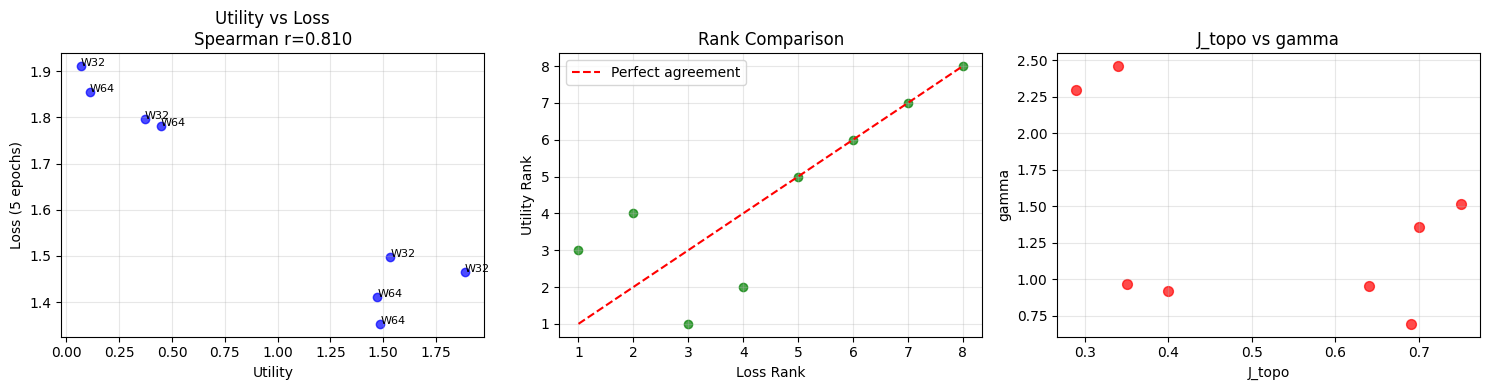

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Utility vs Loss
axes[0].scatter(df['Utility'], df['Loss'], c='blue', alpha=0.7)
for i, row in df.iterrows():
    axes[0].annotate(row['Architecture'].split('-')[0], (row['Utility'], row['Loss']), fontsize=8)
axes[0].set_xlabel('Utility')
axes[0].set_ylabel('Loss (5 epochs)')
axes[0].set_title(f'Utility vs Loss\nSpearman r={spearman_corr:.3f}')
axes[0].grid(True, alpha=0.3)

# Plot 2: Ranking comparison
axes[1].scatter(df['Loss_Rank'], df['Utility_Rank'], c='green', alpha=0.7)
axes[1].plot([1, 8], [1, 8], 'r--', label='Perfect agreement')
axes[1].set_xlabel('Loss Rank')
axes[1].set_ylabel('Utility Rank')
axes[1].set_title('Rank Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: J vs gamma
axes[2].scatter(df['J_topo'], df['gamma'], c='red', alpha=0.7, s=50)
axes[2].set_xlabel('J_topo')
axes[2].set_ylabel('gamma')
axes[2].set_title('J_topo vs gamma')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/phase_b_session2_plots.png', dpi=150)
print("Plots saved to /kaggle/working/phase_b_session2_plots.png")
plt.show()